In [68]:
import pandas as pd

df = pd.read_excel(r"C:\Users\mathe\Downloads\Datathon\data\BASE DE DADOS PEDE 2024 - DATATHON.xlsx")

df.head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 860 entries, 0 to 859
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     860 non-null    str    
 1   Fase                   860 non-null    int64  
 2   Turma                  860 non-null    str    
 3   Nome                   860 non-null    str    
 4   Ano nasc               860 non-null    int64  
 5   Idade 22               860 non-null    int64  
 6   Gênero                 860 non-null    str    
 7   Ano ingresso           860 non-null    int64  
 8   Instituição de ensino  860 non-null    str    
 9   Pedra 20               323 non-null    str    
 10  Pedra 21               462 non-null    str    
 11  Pedra 22               860 non-null    str    
 12  INDE 22                860 non-null    float64
 13  Cg                     860 non-null    int64  
 14  Cf                     860 non-null    int64  
 15  Ct               

In [70]:
df['risco'] = df['Pedra 22'].isin(['Quartzo', 'Ágata']).astype(int)
df['risco'].value_counts()

risco
0    478
1    382
Name: count, dtype: int64

In [71]:
df['Pedra 22'].value_counts()

Pedra 22
Ametista    348
Ágata       250
Quartzo     132
Topázio     130
Name: count, dtype: int64

In [72]:
drop_cols = [
    'INDE 22','Cg','Cf','Ct','Nº Av',
    'Avaliador1','Avaliador2','Rec Av1',
    'Destaque IEG','Destaque IDA','Destaque IPV',
    'Pedra 22','Nome','RA'
]

df_model = df.drop(columns=drop_cols)

In [73]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [74]:
X = df_model.drop('risco', axis=1)
y = df_model['risco']

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [76]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)  # X_train precisa ser DataFrame

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [77]:
from sklearn.metrics import classification_report

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       119
           1       0.97      0.92      0.94        96

    accuracy                           0.95       215
   macro avg       0.95      0.95      0.95       215
weighted avg       0.95      0.95      0.95       215



In [78]:
import pandas as pd
import numpy as np

importances = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'variavel': features,
    'importancia': importances
}).sort_values(by='importancia', ascending=False)

feat_imp.head(15)

,variavel,importancia
7,IDA,0.152748
5,IEG,0.149427
11,IPV,0.118564
8,Matem,0.103999
9,Portug,0.088210
4,IAA,0.039525
13,Defas,0.033404
10,Inglês,0.032642
6,IPS,0.027277
12,IAN,0.026166


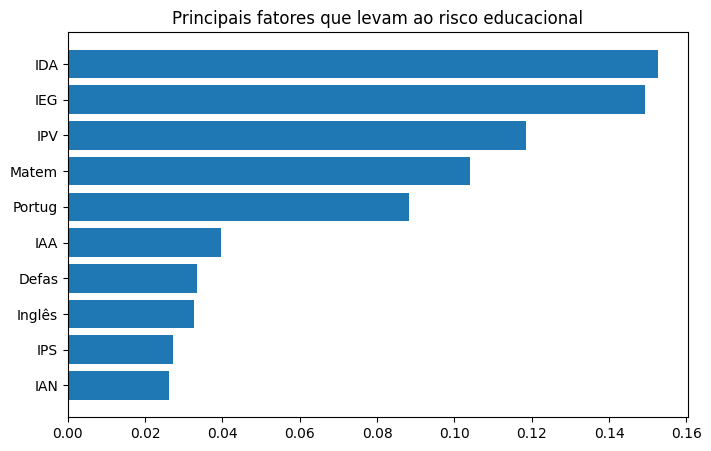

In [79]:
import matplotlib.pyplot as plt

top = feat_imp.head(10)

plt.figure(figsize=(8,5))
plt.barh(top['variavel'][::-1], top['importancia'][::-1])
plt.title("Principais fatores que levam ao risco educacional")
plt.show()

In [80]:
proba = model.predict_proba(X_test)[:,1]

In [81]:
import pandas as pd
resultado = pd.DataFrame({
    'real': y_test,
    'prob_risco': proba
})
resultado.head(10)

,real,prob_risco
741,0,0.340000
20,1,0.576667
671,0,0.206667
105,0,0.076667
693,0,0.010000
308,1,0.863333
504,0,0.056667
283,1,0.886667
791,1,0.463333
399,1,0.933333


In [82]:
def classificar_risco(p):
    if p < 0.30:
        return "Baixo"
    elif p < 0.60:
        return "Moderado"
    elif p < 0.80:
        return "Alto"
    else:
        return "Crítico"

resultado["nivel_risco"] = resultado["prob_risco"].apply(classificar_risco)
resultado.head(10)

,real,prob_risco,nivel_risco
741,0,0.340000,Moderado
20,1,0.576667,Moderado
671,0,0.206667,Baixo
105,0,0.076667,Baixo
693,0,0.010000,Baixo
308,1,0.863333,Crítico
504,0,0.056667,Baixo
283,1,0.886667,Crítico
791,1,0.463333,Moderado
399,1,0.933333,Crítico


In [83]:
import joblib
joblib.dump(model, "modelo_risco.pkl")

['modelo_risco.pkl']